In [1]:
# model training

%pip install xgboost scikit-learn -q

import pandas as pd
import numpy as np
import xgboost as xgb
import boto3
import json
import tarfile
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

BUCKET = "cancer-source-data"

# Rebuild matrix from ml_ready (same as 4.1)
df = pd.read_parquet(f"s3://{BUCKET}/processed/ml-ready/")

labels = df[['tumor_sample_barcode', 'cancer_type']].drop_duplicates()
labels = labels.set_index('tumor_sample_barcode')['cancer_type']

matrix = pd.crosstab(df['tumor_sample_barcode'], df['hugo_symbol'])
matrix = (matrix > 0).astype('int8')
matrix['cancer_type'] = labels

le = LabelEncoder()
matrix['label'] = le.fit_transform(matrix['cancer_type'])
label_map = dict(zip(le.transform(le.classes_), le.classes_))
print("Label map:", label_map)

gene_cols = [c for c in matrix.columns if c not in ('cancer_type', 'label')]

X = matrix[gene_cols]
y = matrix['label']
patient_ids = matrix.index

X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X, y, patient_ids,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Train XGBoost directly
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_test,  label=y_test)

params = {
    "objective":        "multi:softprob",
    "num_class":        5,
    "eval_metric":      "mlogloss",
    "seed":             42
}

evals_result = {}
model = xgb.train(
    params,
    dtrain,
    num_boost_round=200,
    evals=[(dtrain, "train"), (dval, "validation")],
    early_stopping_rounds=10,
    evals_result=evals_result,
    verbose_eval=10
)

print(f"\nBest iteration: {model.best_iteration}")
print(f"Best validation mlogloss: {model.best_score:.4f}")

Note: you may need to restart the kernel to use updated packages.
Label map: {np.int64(0): 'BRCA', np.int64(1): 'COAD', np.int64(2): 'KIRC', np.int64(3): 'LUAD', np.int64(4): 'PRAD'}
[0]	train-mlogloss:1.32157	validation-mlogloss:1.36426
[10]	train-mlogloss:0.59071	validation-mlogloss:0.88516
[20]	train-mlogloss:0.41105	validation-mlogloss:0.80677
[30]	train-mlogloss:0.32455	validation-mlogloss:0.80704
[34]	train-mlogloss:0.30042	validation-mlogloss:0.80261

Best iteration: 24
Best validation mlogloss: 0.7944


In [2]:
# Save model in cloud

os.makedirs("model", exist_ok=True)
model.save_model("model/xgboost-model")

# Package as tar.gz (same format SageMaker would have produced)
with tarfile.open("model.tar.gz", "w:gz") as tar:
    tar.add("model/xgboost-model", arcname="xgboost-model")

# Upload to S3
s3 = boto3.client('s3')
s3.upload_file("model.tar.gz", BUCKET, "models/xgboost-model/model.tar.gz")

model_s3_path = f"s3://{BUCKET}/models/xgboost-model/model.tar.gz"
print(f"Model saved to: {model_s3_path}")

# Also save test set and label map for Phase 4.3
pd.Series(ids_test.values, name='Tumor_Sample_Barcode').to_csv('test_patient_ids.csv', index=False)
with open('label_mapping.json', 'w') as f:
    json.dump({str(k): v for k, v in label_map.items()}, f, indent=2)

s3.upload_file('test_patient_ids.csv', BUCKET, 'processed/model-input/test_patient_ids.csv')
s3.upload_file('label_mapping.json',   BUCKET, 'processed/model-input/label_mapping.json')

print("Test patient IDs and label map uploaded.")
print(f"\nX_test shape: {X_test.shape}")
print(f"y_test distribution:\n{y_test.value_counts().sort_index()}")

/Users/eesha/cancer-classifier/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [13:05:48] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
/Users/eesha/cancer-classifier/venv/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


Model saved to: s3://cancer-source-data/models/xgboost-model/model.tar.gz
Test patient IDs and label map uploaded.

X_test shape: (95, 363)
y_test distribution:
label
0    19
1    20
2    18
3    20
4    18
Name: count, dtype: int64


Note: you may need to restart the kernel to use updated packages.


/Users/eesha/cancer-classifier/venv/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


Accuracy:          0.7368
Weighted F1 score: 0.7397

Per-class breakdown:
              precision    recall  f1-score   support

        BRCA       0.76      0.68      0.72        19
        COAD       0.82      0.70      0.76        20
        KIRC       0.88      0.83      0.86        18
        LUAD       0.68      0.75      0.71        20
        PRAD       0.59      0.72      0.65        18

    accuracy                           0.74        95
   macro avg       0.75      0.74      0.74        95
weighted avg       0.75      0.74      0.74        95



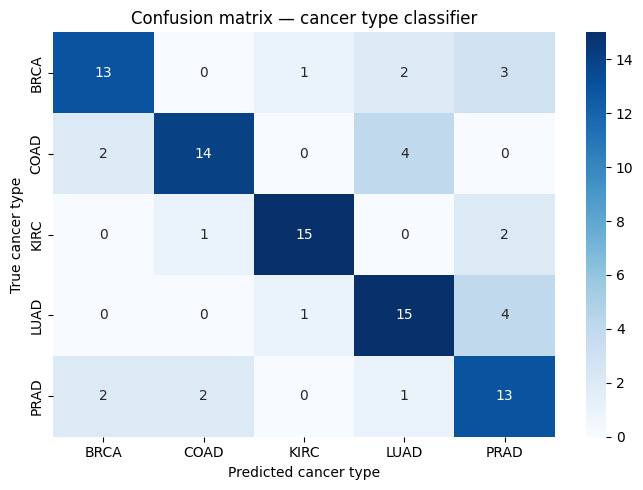

Confusion matrix saved to S3.


In [3]:
# model evaluation

%pip install scikit-learn matplotlib seaborn xgboost -q

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import boto3
import pandas as pd
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

BUCKET = "cancer-source-data"

# Reload model from S3
import tarfile, os
s3 = boto3.client('s3')
s3.download_file(BUCKET, "models/xgboost-model/model.tar.gz", "model.tar.gz")
with tarfile.open("model.tar.gz", "r:gz") as tar:
    tar.extractall("model/")

model = xgb.Booster()
model.load_model("model/xgboost-model")

# Reload test set
df = pd.read_parquet(f"s3://{BUCKET}/processed/ml-ready/")
labels = df[['tumor_sample_barcode', 'cancer_type']].drop_duplicates()
labels = labels.set_index('tumor_sample_barcode')['cancer_type']
matrix = pd.crosstab(df['tumor_sample_barcode'], df['hugo_symbol'])
matrix = (matrix > 0).astype('int8')
matrix['cancer_type'] = labels

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
le = LabelEncoder()
matrix['label'] = le.fit_transform(matrix['cancer_type'])
gene_cols = [c for c in matrix.columns if c not in ('cancer_type', 'label')]
X = matrix[gene_cols]
y = matrix['label']
patient_ids = matrix.index
X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X, y, patient_ids, test_size=0.2, stratify=y, random_state=42
)

# Evaluate
dtest = xgb.DMatrix(X_test)
probs = model.predict(dtest)
y_pred = np.argmax(probs, axis=1)
confidence = probs.max(axis=1)

class_names = ['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD']
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy:          {acc:.4f}")
print(f"Weighted F1 score: {f1:.4f}")
print()
print("Per-class breakdown:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True cancer type')
plt.xlabel('Predicted cancer type')
plt.title('Confusion matrix — cancer type classifier')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

s3.upload_file('confusion_matrix.png', BUCKET, 'output/plots/confusion_matrix.png')
print("Confusion matrix saved to S3.")